In [3]:
import os
import glob
import cv2
import numpy as np

def ensure_dir(directory):
    """Создать папку, если её нет."""
    if not os.path.exists(directory):
        os.makedirs(directory)

def process_image(input_path, 
                  output_dir_binary, 
                  output_dir_noisy, 
                  output_dir_noisy_bin, 
                  output_dir_morph,
                  sigma=20):
    """
    Обрабатывает одно изображение:
      1) Бинаризация исходного
      2) Добавление гауссовского шума
      3) Бинаризация зашумлённого
      4) Морфологическая очистка
    """
    # ---- Чтение исходного изображения ----
    img_name = os.path.basename(input_path)  # например, "A.jpeg"
    img_gray = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"[Предупреждение] Не удалось открыть файл: {input_path}")
        return
    
    # Преобразуем к float32 для удобства при наложении шума
    img_float = img_gray.astype(np.float32)

    # =========================================================
    # 1) БИНАРИЗАЦИЯ ИСХОДНОГО (ЧИСТОГО) ИЗОБРАЖЕНИЯ
    # =========================================================
    # Можно использовать Оцу или адаптивный порог. Для простоты - Оцу:
    _, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Сохраняем результат
    out_bin_path = os.path.join(output_dir_binary, f"{os.path.splitext(img_name)[0]}_bin.png")
    cv2.imwrite(out_bin_path, img_bin)
    
    # =========================================================
    # 2) ГЕНЕРАЦИЯ ГАУССОВСКОГО ШУМА
    # =========================================================
    # Параметр sigma — стандартное отклонение (sqrt(дисперсии))
    noise = np.random.normal(0, sigma, img_float.shape).astype(np.float32)
    noisy_img_float = img_float + noise
    # Ограничим значения в [0..255]
    noisy_img_float = np.clip(noisy_img_float, 0, 255)
    # Возвращаем к uint8
    noisy_img = noisy_img_float.astype(np.uint8)

    # Сохраняем зашумлённое
    out_noisy_path = os.path.join(output_dir_noisy, f"{os.path.splitext(img_name)[0]}_noisy.png")
    cv2.imwrite(out_noisy_path, noisy_img)

    # =========================================================
    # 3) БИНАРИЗАЦИЯ ЗАШУМЛЁННОГО ИЗОБРАЖЕНИЯ
    # =========================================================
    # Иногда полезно сгладить, если шум сильный
    # noisy_blur = cv2.GaussianBlur(noisy_img, (3, 3), 0)
    # _, noisy_bin = cv2.threshold(noisy_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Или напрямую (пример — адаптивный порог):
    noisy_bin = cv2.adaptiveThreshold(noisy_img, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
    out_noisy_bin_path = os.path.join(output_dir_noisy_bin, f"{os.path.splitext(img_name)[0]}_noisy_bin.png")
    cv2.imwrite(out_noisy_bin_path, noisy_bin)

    # =========================================================
    # 4) МОРФОЛОГИЧЕСКАЯ ОБРАБОТКА (ОЧИСТКА)
    # =========================================================
    # Открытие (erosion + dilation) для удаления белых шумовых точек
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(noisy_bin, cv2.MORPH_OPEN, kernel)
    # Закрытие (dilation + erosion) для восстановления структуры символа
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    # Сохраняем результат морфологической обработки
    out_morph_path = os.path.join(output_dir_morph, f"{os.path.splitext(img_name)[0]}_morph.png")
    cv2.imwrite(out_morph_path, closed)

    print(f"Обработано изображение: {img_name}")

def main():
    # Папка с исходными изображениями
    source_folder = "source_images"

    # Папки для сохранения результатов
    output_dir_binary = "results/binary"
    output_dir_noisy = "results/noisy"
    output_dir_noisy_bin = "results/noisy_bin"
    output_dir_morph = "results/morph"

    # Создаём выходные папки (если их нет)
    ensure_dir(output_dir_binary)
    ensure_dir(output_dir_noisy)
    ensure_dir(output_dir_noisy_bin)
    ensure_dir(output_dir_morph)

    # Параметр шума (стандартное отклонение)
    sigma = 20

    # Ищем все .jpeg файлы в папке source_images
    image_paths = glob.glob(os.path.join(source_folder, "*.jpeg"))

    if not image_paths:
        print(f"В папке {source_folder} не найдено файлов .jpeg")
        return

    # Обрабатываем все изображения по очереди
    for path in image_paths:
        process_image(path, 
                      output_dir_binary, 
                      output_dir_noisy, 
                      output_dir_noisy_bin, 
                      output_dir_morph,
                      sigma=sigma)

if __name__ == "__main__":
    main()


Обработано изображение: G.jpeg
Обработано изображение: A.jpeg
Обработано изображение: C.jpeg
Обработано изображение: B.jpeg
Обработано изображение: I.jpeg
Обработано изображение: E.jpeg
Обработано изображение: D.jpeg
Обработано изображение: H.jpeg


In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ensure_dir(directory):
    """Создать папку, если её нет."""
    if not os.path.exists(directory):
        os.makedirs(directory)

def process_image(input_path, 
                  output_dir_binary, 
                  output_dir_noisy, 
                  output_dir_noisy_bin, 
                  output_dir_morph,
                  sigma=20):
    """
    Обрабатывает одно изображение:
      1) Бинаризация исходного
      2) Добавление гауссовского шума
      3) Бинаризация зашумлённого
      4) Морфологическая очистка
      5) Построение и сохранение графиков (изображения + гистограммы)
    """
    img_name = os.path.basename(input_path)  # например, "A.jpeg"
    base_name = os.path.splitext(img_name)[0]

    # ---- Чтение исходного изображения ----
    img_gray = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"[Предупреждение] Не удалось открыть файл: {input_path}")
        return
    
    # Преобразуем к float32 для удобства при наложении шума
    img_float = img_gray.astype(np.float32)

    # =========================================================
    # 1) БИНАРИЗАЦИЯ ИСХОДНОГО (ЧИСТОГО) ИЗОБРАЖЕНИЯ
    # =========================================================
    # Можно использовать Оцу или адаптивный порог. Для простоты - Оцу:
    _, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Сохраняем результат
    out_bin_path = os.path.join(output_dir_binary, f"{base_name}_bin.png")
    cv2.imwrite(out_bin_path, img_bin)
    
    # =========================================================
    # 2) ГЕНЕРАЦИЯ ГАУССОВСКОГО ШУМА
    # =========================================================
    # Параметр sigma — стандартное отклонение (sqrt(дисперсии))
    noise = np.random.normal(0, sigma, img_float.shape).astype(np.float32)
    noisy_img_float = img_float + noise
    # Ограничим значения в [0..255]
    noisy_img_float = np.clip(noisy_img_float, 0, 255)
    # Возвращаем к uint8
    noisy_img = noisy_img_float.astype(np.uint8)

    # Сохраняем зашумлённое
    out_noisy_path = os.path.join(output_dir_noisy, f"{base_name}_noisy.png")
    cv2.imwrite(out_noisy_path, noisy_img)

    # =========================================================
    # 3) БИНАРИЗАЦИЯ ЗАШУМЛЁННОГО ИЗОБРАЖЕНИЯ
    # =========================================================
    # Иногда полезно сгладить, если шум сильный:
    # noisy_blur = cv2.GaussianBlur(noisy_img, (3, 3), 0)
    # _, noisy_bin = cv2.threshold(noisy_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Или напрямую (пример — адаптивный порог):
    noisy_bin = cv2.adaptiveThreshold(noisy_img, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
    out_noisy_bin_path = os.path.join(output_dir_noisy_bin, f"{base_name}_noisy_bin.png")
    cv2.imwrite(out_noisy_bin_path, noisy_bin)

    # =========================================================
    # 4) МОРФОЛОГИЧЕСКАЯ ОБРАБОТКА (ОЧИСТКА)
    # =========================================================
    # Открытие (erosion + dilation) для удаления белых шумовых точек
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(noisy_bin, cv2.MORPH_OPEN, kernel)
    # Закрытие (dilation + erosion) для восстановления структуры символа
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    # Сохраняем результат морфологической обработки
    out_morph_path = os.path.join(output_dir_morph, f"{base_name}_morph.png")
    cv2.imwrite(out_morph_path, closed)

    # =========================================================
    # 5) ПОСТРОЕНИЕ ГРАФИКОВ
    # =========================================================
    # Мы хотим отобразить 4 ключевых изображения:
    #   - Original (img_gray)
    #   - Binary (img_bin)
    #   - Noisy (noisy_img)
    #   - Morph result (closed)
    # И гистограммы для каждого.
    #
    # Создадим Figure 2x4:
    #   строка 0 (верхняя): сами изображения
    #   строка 1 (нижняя): гистограммы
    #
    # При желании можно менять расположение на свой вкус.

    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16,8))

    # --- Верхняя строка: сами изображения ---
    axes[0,0].imshow(img_gray, cmap='gray')
    axes[0,0].set_title("Original")
    axes[0,0].axis('off')  # убрать оси

    axes[0,1].imshow(img_bin, cmap='gray')
    axes[0,1].set_title("Binary (Otsu)")
    axes[0,1].axis('off')

    axes[0,2].imshow(noisy_img, cmap='gray')
    axes[0,2].set_title(f"Noisy (sigma={sigma})")
    axes[0,2].axis('off')

    axes[0,3].imshow(closed, cmap='gray')
    axes[0,3].set_title("Morph result")
    axes[0,3].axis('off')

    # --- Нижняя строка: гистограммы ---
    axes[1,0].hist(img_gray.ravel(), bins=256, range=(0,255))
    axes[1,0].set_title("Hist Original")

    axes[1,1].hist(img_bin.ravel(), bins=256, range=(0,255))
    axes[1,1].set_title("Hist Binary")

    axes[1,2].hist(noisy_img.ravel(), bins=256, range=(0,255))
    axes[1,2].set_title("Hist Noisy")

    axes[1,3].hist(closed.ravel(), bins=256, range=(0,255))
    axes[1,3].set_title("Hist Morph")

    plt.tight_layout()
    
    # Сохраним итоговый рисунок как PNG
    plot_path = os.path.join(output_dir_morph, f"{base_name}_plot.png")
    plt.savefig(plot_path)
    plt.close(fig)

    print(f"Обработано изображение: {img_name}")

def main():
    # Папка с исходными изображениями
    source_folder = "source_images"

    # Папки для сохранения результатов
    output_dir_binary = "results/binary"
    output_dir_noisy = "results/noisy"
    output_dir_noisy_bin = "results/noisy_bin"
    output_dir_morph = "results/morph"

    # Создаём выходные папки (если их нет)
    ensure_dir(output_dir_binary)
    ensure_dir(output_dir_noisy)
    ensure_dir(output_dir_noisy_bin)
    ensure_dir(output_dir_morph)

    # Параметр шума (стандартное отклонение)
    sigma = 20

    # Ищем все .jpeg файлы в папке source_images
    image_paths = glob.glob(os.path.join(source_folder, "*.jpeg"))

    if not image_paths:
        print(f"В папке {source_folder} не найдено файлов .jpeg")
        return

    # Обрабатываем все изображения по очереди
    for path in image_paths:
        process_image(path, 
                      output_dir_binary, 
                      output_dir_noisy, 
                      output_dir_noisy_bin, 
                      output_dir_morph,
                      sigma=sigma)

if __name__ == "__main__":
    main()


Обработано изображение: G.jpeg
Обработано изображение: A.jpeg
Обработано изображение: C.jpeg
Обработано изображение: B.jpeg
Обработано изображение: I.jpeg
Обработано изображение: E.jpeg
Обработано изображение: D.jpeg
Обработано изображение: H.jpeg


In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SECTION 1: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =========================================================

def ensure_dir(directory):
    """Создает папку, если её нет."""
    if not os.path.exists(directory):
        os.makedirs(directory)

def add_gaussian_noise(img_gray, sigma=20):
    """
    Добавление аддитивного гауссовского шума.
    Математически: f'(x) = f(x) + ε(x), где ε(x) ~ N(0, sigma^2).
    Обрезаем значения до диапазона [0, 255].
    """
    float_img = img_gray.astype(np.float32)
    noise = np.random.normal(0, sigma, float_img.shape).astype(np.float32)
    noisy_img = float_img + noise
    noisy_img = np.clip(noisy_img, 0, 255)
    return noisy_img.astype(np.uint8)

def binarize_otsu(img_gray):
    """
    Бинаризация методом Оцу.
    Определяет оптимальный порог T*, минимизируя внутриклассовую дисперсию.
    Возвращает бинарное изображение с пикселями 0 или 255.
    """
    _, bin_img = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bin_img

def morph_open_close(bin_img, ksize=3):
    """
    Морфологическая очистка: 
      - Открытие (erosion + dilation) для удаления мелкого шума.
      - Закрытие (dilation + erosion) для восстановления структуры.
    Математически: opening = (bin_img ⊖ B) ⊕ B, closing = (opening ⊕ B) ⊖ B.
    """
    kernel = np.ones((ksize, ksize), np.uint8)
    opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return closed

def compute_projector(noisy_img, ksize=3, fG=255, fH=0):
    """
    Вычисление проекционной функции для зашумленного изображения.
    Для каждого пикселя x:
      - Локальный минимум f_min(x) = эрозия(noisy_img, B)
      - Локальный максимум f_max(x) = дилатация(noisy_img, B)
      - Нормализуем: φ(x) = (f(x) - f_min(x)) / (f_max(x) - f_min(x)), 
        если знаменатель равен 0, берется φ(x)=0.5.
      - Функция проектора: f_proj(x) = (1 - φ(x))·fG + φ(x)·fH.
    """
    kernel = np.ones((ksize, ksize), np.uint8)
    f_min = cv2.erode(noisy_img, kernel)
    f_max = cv2.dilate(noisy_img, kernel)
    
    img_f = noisy_img.astype(np.float32)
    f_min_f = f_min.astype(np.float32)
    f_max_f = f_max.astype(np.float32)
    
    denominator = f_max_f - f_min_f
    phi = np.empty_like(denominator)
    # Безопасное деление: там, где знаменатель не равен 0
    np.divide(img_f - f_min_f, denominator, out=phi, where=denominator != 0)
    # Там, где знаменатель равен 0, задаем φ(x)=0.5
    phi[denominator == 0] = 0.5
    
    f_proj = (1 - phi) * fG + phi * fH
    f_proj = np.clip(f_proj, 0, 255).astype(np.uint8)
    return f_proj

def recognize_letter(f_proj, ref_folder="source_images", ksize=3, fG=255, fH=0, current_path=None):
    """
    Распознавание буквы по проекционному изображению.
    
    Для каждого эталонного изображения из папки ref_folder (в данном случае source_images):
      1. Считывается изображение (имя файла – название буквы).
      2. Если размер не совпадает с f_proj, масштабируется.
      3. Вычисляется проекционная функция эталона.
      4. Вычисляется мера различия – сумма абсолютных разностей между f_proj и эталонной проекцией.
    
    Чтобы не сравнивать изображение само с собой, файлы с полным путём, совпадающие с current_path, пропускаются.
    
    Буква с минимальной мерой различия считается распознанной.
    Возвращает (распознанная буква, мера различия). Если эталонов нет, возвращает (None, None).
    """
    paths = glob.glob(os.path.join(ref_folder, "*.png")) + glob.glob(os.path.join(ref_folder, "*.jpeg"))
    if not paths:
        print(f"[Warning] Папка {ref_folder} пуста. Эталонные изображения не найдены!")
        return None, None

    best_diff = None
    recognized_letter = None
    for path in paths:
        # Если текущий файл совпадает с тестовым, пропускаем его
        if current_path and os.path.abspath(path) == os.path.abspath(current_path):
            continue
        letter = os.path.splitext(os.path.basename(path))[0]
        ref_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if ref_img is None:
            continue
        if ref_img.shape != f_proj.shape:
            ref_img = cv2.resize(ref_img, (f_proj.shape[1], f_proj.shape[0]))
        ref_proj = compute_projector(ref_img, ksize=ksize, fG=fG, fH=fH)
        diff = np.sum(np.abs(f_proj.astype(np.int32) - ref_proj.astype(np.int32)))
        if best_diff is None or diff < best_diff:
            best_diff = diff
            recognized_letter = letter
    return recognized_letter, best_diff

# =========================================================
# SECTION 2: ОБРАБОТКА ОДНОГО ИЗОБРАЖЕНИЯ (ПАЙПЛАЙН)
# =========================================================

def process_image(input_path, 
                  output_dir_binary, 
                  output_dir_noisy, 
                  output_dir_proj, 
                  output_dir_recog,
                  sigma=20, ksize=3, fG=255, fH=0):
    """
    Пайплайн обработки изображения:
      1. Чтение и бинаризация исходного изображения (эталон).
         [Математически – метод Оцу для поиска порога.]
      2. Добавление гауссовского шума: f'(x) = f(x) + N(0, sigma^2).
      3. Вычисление проекционной функции на зашумлённом изображении:
         φ(x) = (f(x)-f_min(x))/(f_max(x)-f_min(x)), f_proj(x) = (1-φ(x))·fG + φ(x)·fH.
      4. Распознавание буквы по сравнению f_proj с эталонными проекциями из source_images.
         (Текущее изображение исключается из эталонов.)
      5. Построение графиков с промежуточными результатами и выводом результата распознавания.
    """
    img_name = os.path.basename(input_path)
    base_name = os.path.splitext(img_name)[0]

    # --- Чтение исходного изображения ---
    img_gray = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"[Warning] Не удалось открыть файл: {input_path}")
        return
    
    img_float = img_gray.astype(np.float32)

    # 1) Бинаризация исходного изображения (эталон)
    _, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    out_bin_path = os.path.join(output_dir_binary, f"{base_name}_bin.png")
    cv2.imwrite(out_bin_path, img_bin)
    
    # 2) Генерация зашумленного изображения
    noise = np.random.normal(0, sigma, img_float.shape).astype(np.float32)
    noisy_img_float = img_float + noise
    noisy_img_float = np.clip(noisy_img_float, 0, 255)
    noisy_img = noisy_img_float.astype(np.uint8)
    out_noisy_path = os.path.join(output_dir_noisy, f"{base_name}_noisy.png")
    cv2.imwrite(out_noisy_path, noisy_img)
    
    # 3) Вычисление проекционной функции для зашумлённого изображения
    f_proj = compute_projector(noisy_img, ksize=ksize, fG=fG, fH=fH)
    out_proj_path = os.path.join(output_dir_proj, f"{base_name}_proj.png")
    cv2.imwrite(out_proj_path, f_proj)
    
    # 4) Распознавание буквы (используем source_images как эталоны)
    recognized_letter, diff_val = recognize_letter(f_proj, ref_folder="source_images", 
                                                     ksize=ksize, fG=fG, fH=fH, current_path=input_path)
    recog_text = f"Recognized: {recognized_letter} (diff={diff_val})"
    out_recog_txt = os.path.join(output_dir_recog, f"{base_name}_recognized.txt")
    with open(out_recog_txt, "w", encoding="utf-8") as f:
        f.write(recog_text + "\n")
    
    # 5) Построение графиков: отображение исходного, бинарного, зашумленного и проекционного изображений,
    # а также гистограмм для каждого.
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16,8))

    # Верхняя строка: изображения
    axes[0,0].imshow(img_gray, cmap='gray')
    axes[0,0].set_title("Original")
    axes[0,0].axis('off')

    axes[0,1].imshow(img_bin, cmap='gray')
    axes[0,1].set_title("Binary (Otsu)")
    axes[0,1].axis('off')

    axes[0,2].imshow(noisy_img, cmap='gray')
    axes[0,2].set_title(f"Noisy (σ={sigma})")
    axes[0,2].axis('off')

    axes[0,3].imshow(f_proj, cmap='gray')
    axes[0,3].set_title("Projector result")
    axes[0,3].axis('off')

    # Нижняя строка: гистограммы
    axes[1,0].hist(img_gray.ravel(), bins=256, range=(0,255))
    axes[1,0].set_title("Hist Original")

    axes[1,1].hist(img_bin.ravel(), bins=256, range=(0,255))
    axes[1,1].set_title("Hist Binary")

    axes[1,2].hist(noisy_img.ravel(), bins=256, range=(0,255))
    axes[1,2].set_title("Hist Noisy")

    axes[1,3].hist(f_proj.ravel(), bins=256, range=(0,255))
    axes[1,3].set_title("Hist Projector")

    plt.suptitle(recog_text, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    plot_path = os.path.join(output_dir_proj, f"{base_name}_plot.png")
    plt.savefig(plot_path)
    plt.close(fig)
    
    print(f"Обработано изображение: {img_name} -> {recog_text}")

# =========================================================
# SECTION 3: ГЛАВНАЯ ФУНКЦИЯ
# =========================================================

def main():
    # Папки с входными изображениями и для сохранения результатов
    source_folder = "source_images"  # Эталонные изображения теперь тоже в source_images
    output_dir_binary = "results/binary"
    output_dir_noisy = "results/noisy"
    output_dir_proj = "results/proj"      # для проекционных изображений и графиков
    output_dir_recog = "results/recog"    # для текстовых файлов с результатами распознавания
    
    for d in [output_dir_binary, output_dir_noisy, output_dir_proj, output_dir_recog]:
        ensure_dir(d)
    
    # Параметры обработки
    sigma = 20     # стандартное отклонение шума
    ksize = 3      # размер структурного элемента (эрозия/дилатация)
    fG = 255       # яркость фигуры
    fH = 0         # яркость фона
    
    # Ищем все JPEG изображения в папке source_images
    image_paths = glob.glob(os.path.join(source_folder, "*.jpeg"))
    if not image_paths:
        print(f"В папке {source_folder} не найдено файлов .jpeg")
        return

    for path in image_paths:
        process_image(path, output_dir_binary, output_dir_noisy, output_dir_proj, output_dir_recog,
                      sigma=sigma, ksize=ksize, fG=fG, fH=fH)

if __name__ == "__main__":
    main()


Обработано изображение: G.jpeg -> Recognized: E (diff=5669544)
Обработано изображение: A.jpeg -> Recognized: E (diff=4326424)
Обработано изображение: C.jpeg -> Recognized: E (diff=5535412)
Обработано изображение: B.jpeg -> Recognized: E (diff=6726013)
Обработано изображение: I.jpeg -> Recognized: E (diff=5404210)
Обработано изображение: E.jpeg -> Recognized: A (diff=7287438)
Обработано изображение: D.jpeg -> Recognized: E (diff=11998684)
Обработано изображение: H.jpeg -> Recognized: E (diff=4425017)


Загружено 8 изображений, классов: {np.str_('D'), np.str_('G'), np.str_('E'), np.str_('B'), np.str_('I'), np.str_('C'), np.str_('H'), np.str_('A')}
После аугментации обучающая выборка имеет 24 образцов.
Классификатор обучен.
Sigma = 0: Correct = 8/8, Error rate = 0.000
Sigma = 10: Correct = 8/8, Error rate = 0.000
Sigma = 20: Correct = 8/8, Error rate = 0.000
Sigma = 30: Correct = 7/8, Error rate = 0.125
Sigma = 40: Correct = 1/8, Error rate = 0.875
Sigma = 50: Correct = 1/8, Error rate = 0.875


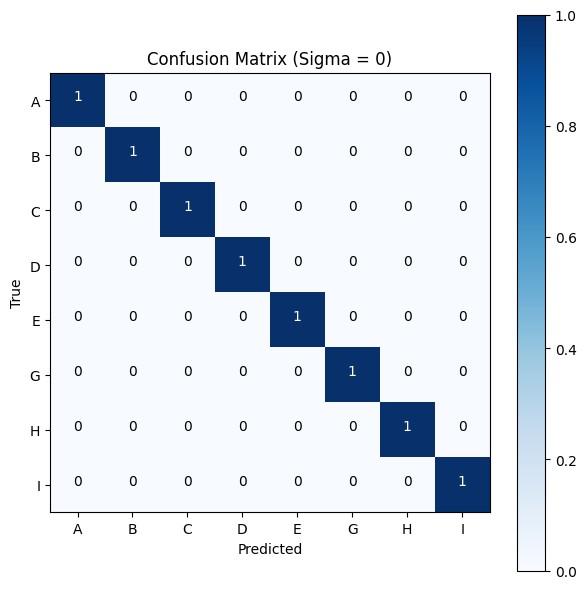

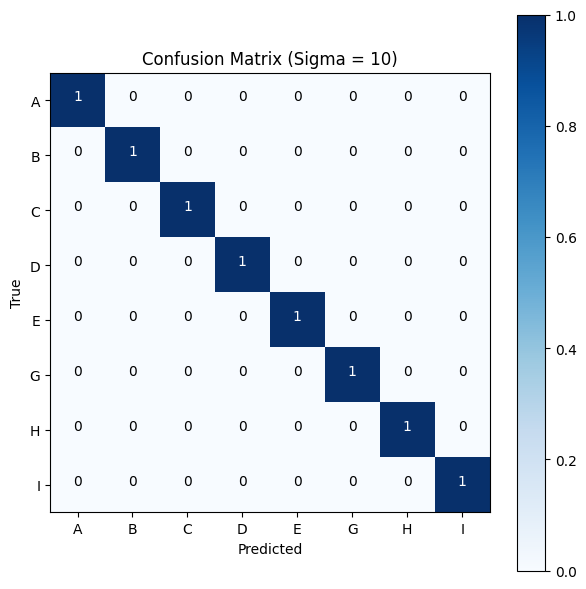

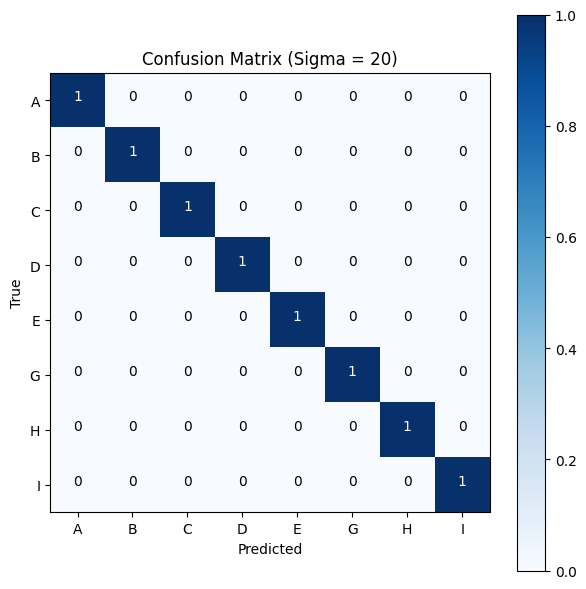

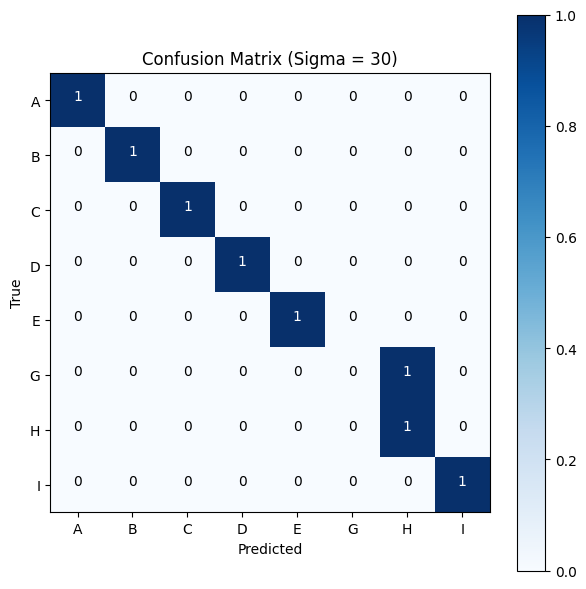

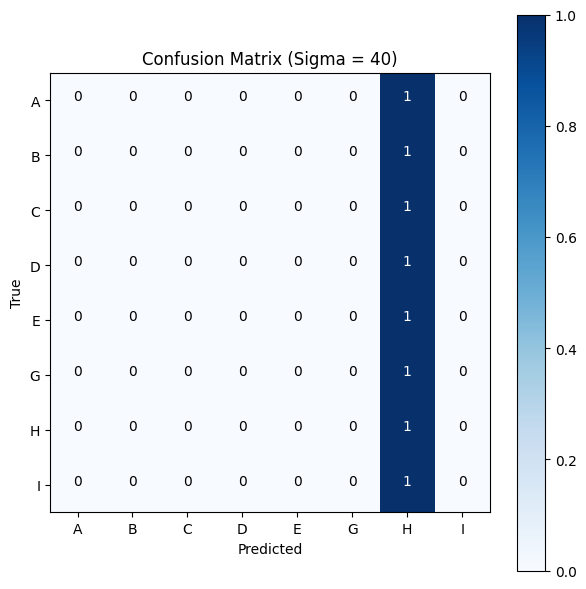

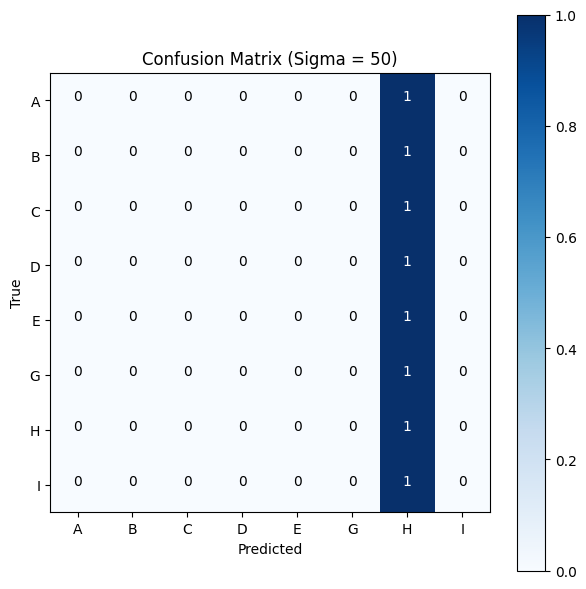

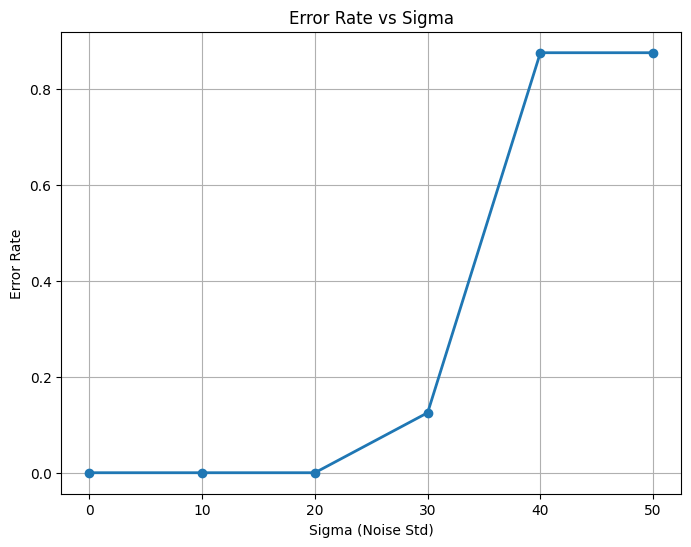

Оценка завершена, результаты сохранены в папке 'results'.


In [2]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# =========================================================
# SECTION 1: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ И АУГМЕНТАЦИЯ
# =========================================================

def ensure_dir(directory):
    """Создает папку, если ее нет."""
    if not os.path.exists(directory):
        os.makedirs(directory)

def get_letter_label(filename):
    """
    Извлекает первую букву из имени файла (в верхнем регистре).
    Например, 'A.jpeg' → 'A'
    """
    base = os.path.splitext(os.path.basename(filename))[0]
    if not base:
        return None
    return base[0].upper()

def load_dataset(source_folder, img_size=(28,28), morph_ksize=0):
    """
    Считывает все изображения из source_folder,
    приводит их к размеру img_size, и формирует X, y, где:
      - X[i] – изображение в виде flatten-вектора (тип float32).
      - y[i] – метка, извлеченная из имени файла.
    Если morph_ksize > 0, выполняется морфологическая очистка.
    """
    image_paths = sorted(glob.glob(os.path.join(source_folder, "*.png")) + 
                         glob.glob(os.path.join(source_folder, "*.jpeg")))
    X = []
    Y = []
    for path in image_paths:
        label = get_letter_label(path)
        if label is None:
            continue
        img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            continue
        if (img_gray.shape[1], img_gray.shape[0]) != img_size:
            img_gray = cv2.resize(img_gray, img_size)
        # При желании можно провести морфологическую обработку
        if morph_ksize > 0:
            kernel = np.ones((morph_ksize, morph_ksize), np.uint8)
            opened = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel)
            closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
            processed = closed
        else:
            processed = img_gray
        X.append(processed.flatten().astype(np.float32))
        Y.append(label)
    return np.array(X), np.array(Y)

def add_gaussian_noise(img, sigma):
    """
    Добавляет гауссов шум со стандартным отклонением sigma к изображению.
    Принимает изображение (float32 или uint8) и возвращает uint8 результат.
    """
    float_img = img.astype(np.float32)
    noise = np.random.normal(0, sigma, float_img.shape).astype(np.float32)
    noisy_img = float_img + noise
    noisy_img = np.clip(noisy_img, 0, 255)
    return noisy_img.astype(np.uint8)

def augment_data(X, y, img_size=(28,28), augment_factor=2, sigma_range=(0,50)):
    """
    Аугментирует обучающую выборку:
    Для каждого изображения генерирует augment_factor дополнений, добавляя шум с sigma, выбранным случайно из sigma_range.
    Возвращает расширенные выборки X_aug и y_aug.
    """
    X_aug = []
    y_aug = []
    for vec, label in zip(X, y):
        # Добавляем чистое изображение
        X_aug.append(vec)
        y_aug.append(label)
        # Преобразуем vector к 2D изображению
        img = vec.reshape(img_size).astype(np.uint8)
        for _ in range(augment_factor):
            sigma = np.random.uniform(sigma_range[0], sigma_range[1])
            noisy_img = add_gaussian_noise(img, sigma)
            X_aug.append(noisy_img.flatten().astype(np.float32))
            y_aug.append(label)
    return np.array(X_aug), np.array(y_aug)

# =========================================================
# SECTION 2: ОБУЧЕНИЕ КЛАССИФИКАТОРА
# =========================================================

def train_classifier(X_train, y_train):
    """
    Создает конвейер из StandardScaler и SVC (метод опорных векторов с RBF-ядром),
    обучает его на предоставленных данных, и возвращает обученную модель.
    """
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=10, gamma="scale"))
    ])
    pipeline.fit(X_train, y_train)
    return pipeline

# =========================================================
# SECTION 3: ОЦЕНКА РАСПОЗНАВАНИЯ ДЛЯ РАЗНЫХ SIGMA
# =========================================================

def evaluate_with_noise(model, X_clean, y_clean, 
                        img_size=(28,28),
                        sigma_list=[0, 10, 20, 30, 40, 50],
                        morph_ksize=0):
    """
    Для каждого sigma из sigma_list:
      - Проходим по всем изображениям из X_clean (которые представляют "чистые" данные).
      - Восстанавливаем 2D изображение, добавляем шум с заданным sigma.
      - (Опционально) Применяем морфологическую обработку, если morph_ksize > 0.
      - Подаем развёрнутый результат в классификатор.
      - Строим матрицу путаницы и считаем долю ошибки.
    
    Возвращает:
      - conf_mats: словарь, где ключ – sigma, значение – матрица путаницы (numpy 2D array).
      - error_rates: словарь, где ключ – sigma, значение – ошибка (от 0 до 1).
      - all_labels: список уникальных меток (в алфавитном порядке).
    """
    all_labels = sorted(list(set(y_clean)))
    conf_mats = {}
    error_rates = {}
    
    for sigma in sigma_list:
        y_pred = []
        y_true = []
        for vec, label in zip(X_clean, y_clean):
            img = vec.reshape(img_size).astype(np.uint8)
            noisy_img = add_gaussian_noise(img, sigma)
            if morph_ksize > 0:
                kernel = np.ones((morph_ksize, morph_ksize), np.uint8)
                noisy_img = cv2.morphologyEx(noisy_img, cv2.MORPH_OPEN, kernel)
                noisy_img = cv2.morphologyEx(noisy_img, cv2.MORPH_CLOSE, kernel)
            x_input = noisy_img.flatten().astype(np.float32).reshape(1, -1)
            pred = model.predict(x_input)[0]
            y_true.append(label)
            y_pred.append(pred)
        cm = confusion_matrix(y_true, y_pred, labels=all_labels)
        total = np.sum(cm)
        correct = np.sum(np.diag(cm))
        err_rate = 1 - (correct/total) if total > 0 else None
        conf_mats[sigma] = cm
        error_rates[sigma] = err_rate
        print(f"Sigma = {sigma}: Correct = {correct}/{total}, Error rate = {err_rate:.3f}")
    return conf_mats, error_rates, all_labels

def plot_conf_mat(cm, labels, sigma):
    """
    Строит и сохраняет визуализацию матрицы путаницы для заданного sigma.
    """
    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Sigma = {sigma})")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    thresh = cm.max() / 2.
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, format(cm[i, j], "d"),
                     horizontalalignment="center",
                     color="white" if cm[i,j] > thresh else "black")
    plt.tight_layout()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    filename = f"results/confusion_matrix_sigma_{sigma}.png"
    plt.savefig(filename)
    plt.show()

def plot_error_rates(error_rates):
    """Строит график зависимости ошибки распознавания от sigma."""
    sigmas = sorted(error_rates.keys())
    errors = [error_rates[s] for s in sigmas]
    plt.figure(figsize=(8,6))
    plt.plot(sigmas, errors, marker='o', linewidth=2)
    plt.xlabel("Sigma (Noise Std)")
    plt.ylabel("Error Rate")
    plt.title("Error Rate vs Sigma")
    plt.grid(True)
    plt.savefig("results/error_rate_vs_sigma.png")
    plt.show()

# =========================================================
# SECTION 4: ГЛАВНАЯ ФУНКЦИЯ
# =========================================================

def main():
    # Путь к датасету (все чистые изображения лежат в source_images)
    source_folder = "source_images"
    ensure_dir("results")
    
    # Загрузим данные: приводим изображения к размеру 28x28, без морфологической очистки при загрузке.
    X_clean, y_clean = load_dataset(source_folder, img_size=(28,28), morph_ksize=0)
    if len(X_clean) == 0:
        print("Нет данных в source_images!")
        return
    print(f"Загружено {len(X_clean)} изображений, классов: {set(y_clean)}")
    
    # Аугментация обучающей выборки: добавим по 2 зашумленных образца на каждое чистое изображение, случайным sigma из [0,50]
    X_aug, y_aug = augment_data(X_clean, y_clean, img_size=(28,28), augment_factor=2, sigma_range=(0,50))
    print(f"После аугментации обучающая выборка имеет {len(X_aug)} образцов.")
    
    # Обучаем классификатор (SVM) на расширенной выборке
    model = train_classifier(X_aug, y_aug)
    print("Классификатор обучен.")
    
    # Задаем список значений sigma для тестирования
    sigma_list = [0, 10, 20, 30, 40, 50]
    
    # Оцениваем распознавание на зашумленных версиях чистых данных
    conf_mats, error_rates, labels = evaluate_with_noise(model, X_clean, y_clean,
                                                         img_size=(28,28),
                                                         sigma_list=sigma_list,
                                                         morph_ksize=0)  # можно задать >0, если нужно
    
    # Строим матрицы путаницы для каждого sigma
    for sigma in sigma_list:
        cm = conf_mats[sigma]
        plot_conf_mat(cm, labels, sigma)
    
    # Строим график зависимости ошибки от sigma
    plot_error_rates(error_rates)
    print("Оценка завершена, результаты сохранены в папке 'results'.")

if __name__ == "__main__":
    main()
